## 1. Configuration, reproductibilite et GPU

In [13]:
# Windows + conda : torch (pip) et numpy/mkl (conda) embarquent chacun libiomp5md.dll.
# Sans cette ligne, le noyau plante (OMP: Error #15). Doit etre execute AVANT import torch.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import os
import json
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- reproductibilite
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fixe toutes les sources d'alea utilisees dans ce notebook."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# ---------------------------------------------------------------- materiel
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"          # mixed precision uniquement sur GPU
PIN_MEMORY = DEVICE.type == "cuda"
# Sur Windows, les workers multiprocess lances depuis un notebook sont instables -> 0.
NUM_WORKERS = 0 if os.name == "nt" else 2

print("torch       :", torch.__version__)
print("device      :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU         :", torch.cuda.get_device_name(0))
    print("memoire GPU : %.1f Go" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print("!! Aucun GPU detecte : le notebook bascule en mode reduit (voir FAST_DEV).")

# ---------------------------------------------------------------- hyperparametres
IMG_SIZE = 224
BATCH_SIZE = 64 if DEVICE.type == "cuda" else 32
VAL_RATIO = 0.15

# Sans GPU, on reduit fortement pour que le notebook reste executable de bout en bout.
FAST_DEV = DEVICE.type != "cuda"
EPOCHS_SCRATCH = 2 if FAST_DEV else 12
EPOCHS_TRANSFER = 1 if FAST_DEV else 5
EPOCHS_FINETUNE = 1 if FAST_DEV else 3
DATA_FRACTION = 0.05 if FAST_DEV else 1.0   # fraction du train reellement utilisee

CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
RUNS_DIR = Path("runs"); RUNS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)

print("\nFAST_DEV = %s | epochs scratch = %d | epochs transfert = %d | fraction data = %.2f"
      % (FAST_DEV, EPOCHS_SCRATCH, EPOCHS_TRANSFER, DATA_FRACTION))

torch       : 2.14.0+cpu
device      : cpu
!! Aucun GPU detecte : le notebook bascule en mode reduit (voir FAST_DEV).

FAST_DEV = True | epochs scratch = 2 | epochs transfert = 1 | fraction data = 0.05


## 2. Donnees : split train / validation / test

Le dossier `Cat_Dog_data/test` sert **uniquement** au test final. Le jeu de validation est
decoupe dans `Cat_Dog_data/train`, de facon **stratifiee** (meme proportion de chats et de
chiens des deux cotes) et **reproductible** (generateur seede).

Point important : le split porte sur des *indices*, et deux `ImageFolder` distincts sont
construits sur le meme dossier - un avec l'augmentation, un sans. Les images de validation
ne subissent ainsi jamais de transformation aleatoire.

In [14]:
DATA_DIR = Path("Cat_Dog_data")

# Statistiques ImageNet : indispensables pour le transfer learning, et utiles aussi pour le
# modele from scratch (entrees centrees -> gradients mieux conditionnes).
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomRotation(15),                              # rotation AVANT le crop
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),   # -> pas de bords noirs
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),   # obligatoire : sinon les tenseurs n'ont pas tous la meme taille
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# --- split stratifie train / validation -------------------------------------------
index_ds = datasets.ImageFolder(DATA_DIR / "train")
CLASSES = index_ds.classes
NUM_CLASSES = len(CLASSES)
targets = np.array(index_ds.targets)

rng = np.random.default_rng(SEED)
val_parts, train_parts = [], []
for c in range(NUM_CLASSES):
    idx_c = np.where(targets == c)[0]
    rng.shuffle(idx_c)
    if DATA_FRACTION < 1.0:
        idx_c = idx_c[: max(2, int(len(idx_c) * DATA_FRACTION))]
    n_val = max(1, int(round(VAL_RATIO * len(idx_c))))
    val_parts.append(idx_c[:n_val])
    train_parts.append(idx_c[n_val:])

val_idx = np.concatenate(val_parts)
train_idx = np.concatenate(train_parts)

train_ds = Subset(datasets.ImageFolder(DATA_DIR / "train", transform=train_tf), train_idx)
val_ds = Subset(datasets.ImageFolder(DATA_DIR / "train", transform=eval_tf), val_idx)
test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_tf)

assert len(set(train_idx.tolist()) & set(val_idx.tolist())) == 0, "fuite entre train et validation !"

def make_loader(dataset, shuffle: bool, batch_size: int = BATCH_SIZE) -> DataLoader:
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, generator=generator,
        persistent_workers=NUM_WORKERS > 0, drop_last=False,
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

print("classes    :", CLASSES, index_ds.class_to_idx)
print("train      : %5d images" % len(train_ds),
      dict(zip(CLASSES, np.bincount(targets[train_idx], minlength=NUM_CLASSES).tolist())))
print("validation : %5d images" % len(val_ds),
      dict(zip(CLASSES, np.bincount(targets[val_idx], minlength=NUM_CLASSES).tolist())))
print("test       : %5d images" % len(test_ds),
      dict(zip(CLASSES, np.bincount(np.array(test_ds.targets), minlength=NUM_CLASSES).tolist())))

classes    : ['cat', 'dog'] {'cat': 0, 'dog': 1}
train      :   956 images {'cat': 478, 'dog': 478}
validation :   168 images {'cat': 84, 'dog': 84}
test       :  2500 images {'cat': 1250, 'dog': 1250}


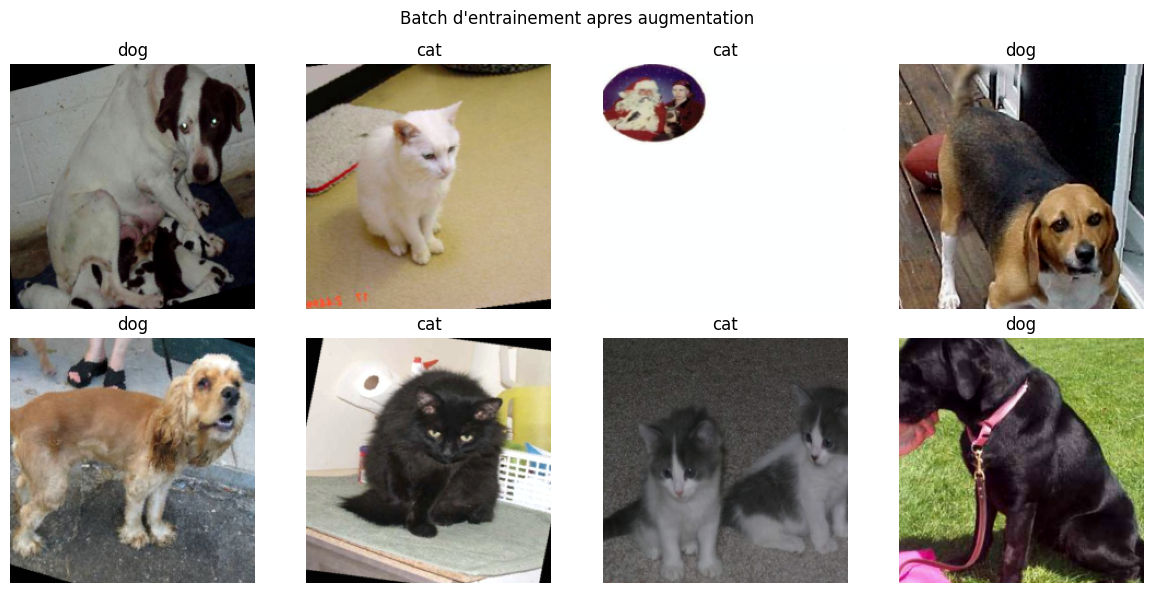

shape du batch : (32, 3, 224, 224) | classes presentes dans le batch : [0, 1]


In [15]:
# Verification visuelle de l'augmentation appliquee au train.
def denormalize(t: torch.Tensor) -> np.ndarray:
    img = t.cpu().numpy().transpose(1, 2, 0)
    return np.clip(np.array(STD) * img + np.array(MEAN), 0, 1)

batch_images, batch_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lab in zip(axes.ravel(), batch_images, batch_labels):
    ax.imshow(denormalize(img))
    ax.set_title(CLASSES[lab])
    ax.axis("off")
fig.suptitle("Batch d'entrainement apres augmentation")
plt.tight_layout()
plt.show()

print("shape du batch :", tuple(batch_images.shape),
      "| classes presentes dans le batch :", sorted(set(batch_labels.tolist())))

## 3. Metriques

`accuracy`, `precision` et `recall` sont derives d'une **matrice de confusion** accumulee sur
l'epoque entiere (plutot que moyennes batch par batch, ce qui serait biaise par le dernier
batch incomplet). Precision et recall sont donnes en **macro-moyenne** ; le detail par classe
est conserve pour l'analyse finale. Aucune dependance a scikit-learn n'est necessaire.

In [16]:
def confusion_matrix(preds: torch.Tensor, targets: torch.Tensor,
                     num_classes: int = NUM_CLASSES) -> torch.Tensor:
    """Matrice de confusion [vrai, predit], calculee de facon vectorisee."""
    k = targets.to(torch.int64) * num_classes + preds.to(torch.int64)
    return torch.bincount(k, minlength=num_classes ** 2).reshape(num_classes, num_classes)


def metrics_from_cm(cm: torch.Tensor) -> dict:
    """Accuracy globale + precision / recall / F1 macro et par classe."""
    cm = cm.double()
    tp = cm.diag()
    support = cm.sum(dim=1)      # nombre de vrais exemples de chaque classe
    predicted = cm.sum(dim=0)    # nombre de predictions de chaque classe
    zero = torch.zeros_like(tp)
    precision = torch.where(predicted > 0, tp / predicted.clamp(min=1), zero)
    recall = torch.where(support > 0, tp / support.clamp(min=1), zero)
    f1 = 2 * precision * recall / (precision + recall).clamp(min=1e-12)
    return {
        "accuracy": (tp.sum() / cm.sum().clamp(min=1)).item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
        "f1": f1.mean().item(),
        "precision_per_class": precision.tolist(),
        "recall_per_class": recall.tolist(),
    }


# Verification sur un cas connu : 2 vrais 0, 1 faux positif, 1 vrai 1.
_cm = confusion_matrix(torch.tensor([0, 1, 1, 0]), torch.tensor([0, 1, 0, 0]))
assert _cm.tolist() == [[2, 1], [0, 1]], _cm.tolist()
print(_cm.tolist(), "-> accuracy %.2f" % metrics_from_cm(_cm)["accuracy"])

[[2, 1], [0, 1]] -> accuracy 0.75


## 4. Boucle d'entrainement

Une seule fonction `fit` sert aux deux experiences : la comparaison porte ainsi sur les
**modeles** et non sur des boucles d'entrainement differentes. Elle gere :

* les metriques train **et** validation a chaque epoque,
* le `scheduler` de learning rate,
* la journalisation TensorBoard dans `runs/<nom>`,
* la sauvegarde du **meilleur** checkpoint (accuracy de validation) dans `checkpoints/`,
* la mixed precision quand un GPU est disponible.

In [6]:
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_OK = True
except ImportError:      # tensorboard non installe : on continue sans journalisation
    SummaryWriter = None
    TENSORBOARD_OK = False
    print("tensorboard indisponible (pip install tensorboard) : journalisation desactivee.")


def make_scaler():
    """GradScaler compatible avec les API torch anciennes et recentes."""
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda")
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler()


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    """Une epoque. optimizer=None -> evaluation (pas de gradient, dropout desactive)."""
    is_train = optimizer is not None
    model.train(is_train)

    running_loss, seen = 0.0, 0
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        running_loss += loss.item() * labels.size(0)
        seen += labels.size(0)
        cm += confusion_matrix(logits.detach().argmax(dim=1).cpu(), labels.cpu())

    stats = metrics_from_cm(cm)
    stats["loss"] = running_loss / max(seen, 1)
    stats["cm"] = cm
    return stats


def fit(model, run_name, optimizer, epochs, train_loader, val_loader,
        scheduler=None, criterion=None, checkpoint=True, verbose=True):
    """Entraine le modele et renvoie (history, chemin_du_meilleur_checkpoint)."""
    model = model.to(DEVICE)
    criterion = criterion or nn.CrossEntropyLoss()
    scaler = make_scaler()
    writer = SummaryWriter(str(RUNS_DIR / run_name)) if TENSORBOARD_OK else None

    history = {"epoch": [], "lr": []}
    for split in ("train", "val"):
        for metric in ("loss", "accuracy", "precision", "recall", "f1"):
            history["%s_%s" % (split, metric)] = []

    ckpt_path = CKPT_DIR / ("%s_best.pt" % run_name)
    best_acc, t0 = -1.0, time.time()

    for epoch in range(1, epochs + 1):
        lr = optimizer.param_groups[0]["lr"]
        tr = run_epoch(model, train_loader, criterion, optimizer, scaler)
        va = run_epoch(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        history["epoch"].append(epoch)
        history["lr"].append(lr)
        for metric in ("loss", "accuracy", "precision", "recall", "f1"):
            history["train_%s" % metric].append(tr[metric])
            history["val_%s" % metric].append(va[metric])

        if writer is not None:
            for metric in ("loss", "accuracy", "precision", "recall", "f1"):
                writer.add_scalars(metric, {"train": tr[metric], "val": va[metric]}, epoch)
            writer.add_scalar("lr", lr, epoch)

        improved = va["accuracy"] > best_acc
        if checkpoint and improved:
            best_acc = va["accuracy"]
            torch.save({
                "run_name": run_name,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "val_accuracy": va["accuracy"],
                "classes": CLASSES,
                "img_size": IMG_SIZE,
                "normalize": {"mean": MEAN, "std": STD},
                "seed": SEED,
            }, ckpt_path)
        elif improved:
            best_acc = va["accuracy"]

        if verbose:
            print("[%s] epoch %2d/%d | lr %.2e | train loss %.4f acc %.4f "
                  "| val loss %.4f acc %.4f prec %.4f rec %.4f%s"
                  % (run_name, epoch, epochs, lr, tr["loss"], tr["accuracy"],
                     va["loss"], va["accuracy"], va["precision"], va["recall"],
                     "  <- best" if improved else ""))

    if writer is not None:
        writer.close()
    if verbose:
        print("%s : termine en %.1f s | meilleure val accuracy = %.4f | checkpoint -> %s"
              % (run_name, time.time() - t0, best_acc, ckpt_path))
    return history, ckpt_path

tensorboard indisponible (pip install tensorboard) : journalisation desactivee.


## 5. Experience A - CNN *from scratch*

Architecture : **4 blocs convolutifs** (l'enonce en demande 3 au minimum), chacun compose de
`Conv -> BatchNorm -> ReLU` repete deux fois, puis `MaxPool` et `Dropout2d`.

**Ou sont places BatchNorm et Dropout, et pourquoi :**

* `BatchNorm2d` est place **apres la convolution et avant la ReLU**, dans chaque bloc. Il
  renormalise les activations par batch, ce qui stabilise la distribution vue par la couche
  suivante, autorise un learning rate plus eleve et accelere nettement la convergence d'un
  reseau entraine de zero. Les convolutions qui le precedent sont declarees `bias=False` :
  le biais serait de toute facon annule par le centrage de BatchNorm.
* `Dropout2d` (faible, 0.05 -> 0.20 en profondeur) est place **apres le pooling**. Sur des
  cartes de features, le dropout element par element est peu efficace car les pixels voisins
  sont fortement correles ; `Dropout2d` supprime des canaux entiers. Le taux augmente avec la
  profondeur, la ou le nombre de parametres - et donc le risque de surapprentissage - est le
  plus grand.
* Un `Dropout` classique (0.5) est place **juste avant la couche de classification**, la ou
  la capacite de memorisation est maximale : c'est la que la regularisation rapporte le plus.
* Le `AdaptiveAvgPool2d(1)` remplace un gros `Flatten + Linear` : il divise par ~100 le nombre
  de parametres de la tete et constitue lui-meme une forme de regularisation.

In [ ]:
class ConvBlock(nn.Module):
    """Conv-BN-ReLU x2, puis MaxPool et Dropout2d."""

    def __init__(self, in_channels: int, out_channels: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class ScratchCNN(nn.Module):
    """CNN entraine de zero : 4 blocs convolutifs + tete de classification."""

    def __init__(self, num_classes: int = NUM_CLASSES, head_dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, 0.05),     
            ConvBlock(32, 64, 0.10),    
            ConvBlock(64, 128, 0.15),   
            ConvBlock(128, 256, 0.20),  
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(head_dropout),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


set_seed()
_demo = ScratchCNN()
print(_demo)
print("\nparametres (total / entrainables) : %s / %s" % tuple(format(n, ",") for n in count_parameters(_demo)))
print("sortie sur un batch factice :", tuple(_demo(torch.randn(2, 3, IMG_SIZE, IMG_SIZE)).shape))
del _demo

ScratchCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=

### 5.1 Choix de l'optimiseur et du learning rate

L'enonce demande de tester au moins deux optimiseurs. La recherche se fait sur un
**sous-echantillon** du train et sur peu d'epoques : l'objectif est de comparer des debuts de
trajectoire, pas d'atteindre la performance finale. Les modeles sont reinitialises avec le
meme seed avant chaque essai, la comparaison est donc equitable.

In [8]:
SEARCH_TRAIN_N = min(len(train_ds), 300 if FAST_DEV else 4000)
SEARCH_VAL_N = min(len(val_ds), 100 if FAST_DEV else 1000)
SEARCH_EPOCHS = 1 if FAST_DEV else 3

# train_ds est ordonne par classe (tous les chats puis tous les chiens) : prendre les N
# premiers indices donnerait un sous-ensemble mono-classe. On tire donc au hasard, de
# facon reproductible.
_rng = np.random.default_rng(SEED)
_train_pick = _rng.permutation(len(train_ds))[:SEARCH_TRAIN_N].tolist()
_val_pick = _rng.permutation(len(val_ds))[:SEARCH_VAL_N].tolist()

search_train_loader = make_loader(Subset(train_ds, _train_pick), shuffle=True)
search_val_loader = make_loader(Subset(val_ds, _val_pick), shuffle=False)

SEARCH_GRID = [
    ("sgd", 0.1), ("sgd", 0.01), ("sgd", 0.001),
    ("adam", 1e-3), ("adam", 3e-4), ("adam", 1e-4),
]

def build_optimizer(name: str, params, lr: float):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=1e-4)
    raise ValueError("optimiseur inconnu : %s" % name)


search_results = []
for opt_name, lr in SEARCH_GRID:
    set_seed()                                   # meme initialisation pour tous les essais
    model = ScratchCNN().to(DEVICE)
    optimizer = build_optimizer(opt_name, model.parameters(), lr)
    history, _ = fit(model, "search_%s_lr%g" % (opt_name, lr), optimizer, SEARCH_EPOCHS,
                     search_train_loader, search_val_loader, checkpoint=False, verbose=False)
    search_results.append({
        "optimizer": opt_name, "lr": lr,
        "val_accuracy": history["val_accuracy"][-1],
        "val_loss": history["val_loss"][-1],
    })
    print("%-5s lr=%-8g -> val acc %.4f | val loss %.4f"
          % (opt_name, lr, search_results[-1]["val_accuracy"], search_results[-1]["val_loss"]))
    del model, optimizer

best_setting = max(search_results, key=lambda r: (r["val_accuracy"], -r["val_loss"]))
print("\nMeilleure configuration de depart :", best_setting)
(RESULTS_DIR / "lr_search.json").write_text(json.dumps(search_results, indent=2), encoding="utf-8")

sgd   lr=0.1      -> val acc 0.4700 | val loss 1548.7150
sgd   lr=0.01     -> val acc 0.4700 | val loss 0.7409
sgd   lr=0.001    -> val acc 0.4700 | val loss 0.6951
adam  lr=0.001    -> val acc 0.4700 | val loss 0.8016
adam  lr=0.0003   -> val acc 0.4700 | val loss 0.7417
adam  lr=0.0001   -> val acc 0.4700 | val loss 0.6981

Meilleure configuration de depart : {'optimizer': 'sgd', 'lr': 0.001, 'val_accuracy': 0.47, 'val_loss': 0.6951197576522827}


667

### 5.2 Entrainement complet avec les deux optimiseurs

Les deux optimiseurs sont ensuite entraines **entierement**, chacun avec son meilleur learning
rate, pour pouvoir comparer les courbes en partie 7. Un `CosineAnnealingLR` fait decroitre le
learning rate jusqu'a ~0 sur la duree de l'entrainement (bonus *scheduler*).

In [9]:
def best_lr_for(optimizer_name: str) -> float:
    candidates = [r for r in search_results if r["optimizer"] == optimizer_name]
    return max(candidates, key=lambda r: (r["val_accuracy"], -r["val_loss"]))["lr"]

scratch_histories, scratch_ckpts = {}, {}

for opt_name in ("sgd", "adam"):
    lr = best_lr_for(opt_name)
    set_seed()
    model = ScratchCNN().to(DEVICE)
    optimizer = build_optimizer(opt_name, model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SCRATCH)
    run_name = "cnn_from_scratch_%s" % opt_name
    print("\n=== Experience A - %s (lr = %g) ===" % (opt_name.upper(), lr))
    history, ckpt = fit(model, run_name, optimizer, EPOCHS_SCRATCH,
                        train_loader, val_loader, scheduler=scheduler)
    scratch_histories[opt_name] = history
    scratch_ckpts[opt_name] = ckpt
    del model, optimizer

# Le meilleur des deux represente l'experience A pour le test final.
BEST_SCRATCH_OPT = max(scratch_histories, key=lambda k: max(scratch_histories[k]["val_accuracy"]))
SCRATCH_CKPT = scratch_ckpts[BEST_SCRATCH_OPT]
print("\nMeilleur optimiseur from scratch : %s (val acc = %.4f)"
      % (BEST_SCRATCH_OPT, max(scratch_histories[BEST_SCRATCH_OPT]["val_accuracy"])))


=== Experience A - SGD (lr = 0.001) ===
[cnn_from_scratch_sgd] epoch  1/2 | lr 1.00e-03 | train loss 0.6973 acc 0.5042 | val loss 0.6736 acc 0.5357 prec 0.6169 rec 0.5357  <- best
[cnn_from_scratch_sgd] epoch  2/2 | lr 5.00e-04 | train loss 0.6795 acc 0.5680 | val loss 0.6610 acc 0.5774 prec 0.6434 rec 0.5774  <- best
cnn_from_scratch_sgd : termine en 328.1 s | meilleure val accuracy = 0.5774 | checkpoint -> checkpoints\cnn_from_scratch_sgd_best.pt

=== Experience A - ADAM (lr = 0.0001) ===
[cnn_from_scratch_adam] epoch  1/2 | lr 1.00e-04 | train loss 0.6805 acc 0.5764 | val loss 0.6851 acc 0.5536 prec 0.7642 rec 0.5536  <- best
[cnn_from_scratch_adam] epoch  2/2 | lr 5.00e-05 | train loss 0.6605 acc 0.5962 | val loss 0.6471 acc 0.5714 prec 0.5875 rec 0.5714  <- best
cnn_from_scratch_adam : termine en 393.5 s | meilleure val accuracy = 0.5714 | checkpoint -> checkpoints\cnn_from_scratch_adam_best.pt

Meilleur optimiseur from scratch : sgd (val acc = 0.5774)


## 6. Experience B - Transfer learning (ResNet18)

Strategie en deux temps, classique et economique :

1. **Extraction de features** - le backbone pre-entraine sur ImageNet est gele, seule la
   nouvelle tete (`Dropout` + `Linear`) est entrainee. On peut alors utiliser un learning rate
   confortable, puisque les poids pre-entraines ne bougent pas.
2. **Fine-tuning** - on degele le dernier bloc residuel (`layer4`) avec un learning rate dix
   fois plus faible, pour adapter les features les plus specifiques sans detruire ce que le
   reseau a deja appris.

Detail qui compte : quand le backbone est gele, les couches `BatchNorm` sont forcees en mode
`eval`. Sinon, meme sans gradient, elles continueraient a mettre a jour leurs statistiques
courantes sur nos donnees et modifieraient silencieusement les features censees etre gelees.

In [10]:
class TransferModel(nn.Module):
    """ResNet18 pre-entraine ImageNet, tete remplacee, backbone gelable."""

    def __init__(self, num_classes: int = NUM_CLASSES, dropout: float = 0.3, freeze: bool = True):
        super().__init__()
        try:
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            self.backbone = models.resnet18(weights=weights)
        except AttributeError:                       # torchvision < 0.13
            self.backbone = models.resnet18(pretrained=True)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),                     # regularisation de la tete
            nn.Linear(in_features, num_classes),
        )
        self.frozen = False
        if freeze:
            self.freeze_backbone()

    def freeze_backbone(self):
        for name, param in self.backbone.named_parameters():
            param.requires_grad = name.startswith("fc.")
        self.frozen = True

    def unfreeze(self, prefixes=("layer4", "fc")):
        for name, param in self.backbone.named_parameters():
            param.requires_grad = any(name.startswith(p) for p in prefixes)
        self.frozen = False

    def train(self, mode: bool = True):
        super().train(mode)
        if mode and self.frozen:
            # backbone gele -> BatchNorm en eval pour figer les statistiques courantes
            for module in self.backbone.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()
        return self

    def forward(self, x):
        return self.backbone(x)


set_seed()
transfer_model = TransferModel().to(DEVICE)
total, trainable_n = count_parameters(transfer_model)
print("parametres : %s au total, %s entrainables (%.2f %%)"
      % (format(total, ","), format(trainable_n, ","), 100 * trainable_n / total))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\daniel.lelano/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


parametres : 11,177,538 au total, 1,026 entrainables (0.01 %)


In [11]:
# --- Phase 1 : extraction de features (backbone gele) ---------------------------
trainable = [p for p in transfer_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable, lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_TRANSFER)

print("=== Experience B - phase 1 : extraction de features ===")
transfer_history, TRANSFER_CKPT = fit(
    transfer_model, "transfer_resnet18_frozen", optimizer, EPOCHS_TRANSFER,
    train_loader, val_loader, scheduler=scheduler,
)

=== Experience B - phase 1 : extraction de features ===
[transfer_resnet18_frozen] epoch  1/1 | lr 1.00e-03 | train loss 0.4000 acc 0.8128 | val loss 0.1384 acc 0.9583 prec 0.9589 rec 0.9583  <- best
transfer_resnet18_frozen : termine en 51.3 s | meilleure val accuracy = 0.9583 | checkpoint -> checkpoints\transfer_resnet18_frozen_best.pt


In [ ]:
# --- Phase 2 : fine-tuning de layer4 avec un learning rate reduit ---------------
transfer_model.unfreeze(prefixes=("layer4", "fc"))
total, trainable_n = count_parameters(transfer_model)
print("apres degel : %s parametres entrainables sur %s" % (format(trainable_n, ","), format(total, ",")))

trainable = [p for p in transfer_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

print("\n=== Experience B - phase 2 : fine-tuning ===")
finetune_history, FINETUNE_CKPT = fit(
    transfer_model, "transfer_resnet18_finetuned", optimizer, EPOCHS_FINETUNE,
    train_loader, val_loader, scheduler=scheduler,
)

# Historique complet de l'experience B : phase 1 puis phase 2 bout a bout.
transfer_full_history = {}
for key, values in transfer_history.items():
    if key == "epoch":
        transfer_full_history[key] = list(range(1, EPOCHS_TRANSFER + EPOCHS_FINETUNE + 1))
    else:
        transfer_full_history[key] = values + finetune_history[key]

best_frozen = max(transfer_history["val_accuracy"])
best_finetuned = max(finetune_history["val_accuracy"])
TRANSFER_BEST_CKPT = TRANSFER_CKPT if best_frozen >= best_finetuned else FINETUNE_CKPT
print("\nval acc - gele : %.4f | fine-tune : %.4f | checkpoint retenu : %s"
      % (best_frozen, best_finetuned, TRANSFER_BEST_CKPT))

## 7. Courbes comparatives

In [ ]:
def plot_curves(histories: dict, metrics=("loss", "accuracy", "precision", "recall")):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, metric in zip(axes.ravel(), metrics):
        for i, (label, hist) in enumerate(histories.items()):
            color = colors[i % len(colors)]
            ax.plot(hist["epoch"], hist["train_%s" % metric], color=color,
                    linestyle="--", alpha=0.65, label="%s (train)" % label)
            ax.plot(hist["epoch"], hist["val_%s" % metric], color=color,
                    linestyle="-", marker="o", markersize=3, label="%s (val)" % label)
        ax.set_title(metric.capitalize())
        ax.set_xlabel("epoque")
        ax.grid(alpha=0.3)
        if metric != "loss":
            ax.set_ylim(0, 1.02)
    axes.ravel()[0].legend(fontsize=8)

    fig.suptitle("From scratch vs transfer learning - trait plein = validation, pointille = train")
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "curves_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()


all_histories = {
    "scratch (SGD)": scratch_histories["sgd"],
    "scratch (Adam)": scratch_histories["adam"],
    "transfert ResNet18": transfer_full_history,
}
plot_curves(all_histories)
print("Figure enregistree :", RESULTS_DIR / "curves_comparison.png")

In [ ]:
# Evolution du learning rate (effet du scheduler cosinus).
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, hist in all_histories.items():
    ax.plot(hist["epoch"], hist["lr"], marker="o", markersize=3, label=label)
ax.set_yscale("log")
ax.set_xlabel("epoque")
ax.set_ylabel("learning rate")
ax.set_title("Planification du learning rate")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Test final : rechargement des checkpoints

Les modeles sont **reconstruits vides puis recharges depuis le disque**, comme le demande
l'enonce : c'est la seule facon de verifier que les checkpoints sont reellement exploitables.
Le jeu de test (`Cat_Dog_data/test`) n'a servi ni a l'entrainement ni a la selection des
hyperparametres.

In [ ]:
def load_checkpoint(path, model_factory):
    try:
        ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:                     # torch < 2.0 : pas d'argument weights_only
        ckpt = torch.load(path, map_location=DEVICE)
    model = model_factory().to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print("charge : %s (epoque %d, val acc %.4f)" % (path, ckpt["epoch"], ckpt["val_accuracy"]))
    return model, ckpt


@torch.no_grad()
def evaluate(model, loader):
    """Evaluation complete : metriques + predictions + probabilites."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, seen = 0.0, 0
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    all_preds, all_targets, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        seen += labels.size(0)
        cm += confusion_matrix(preds.cpu(), labels.cpu())
        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())
        all_probs.append(probs.cpu())

    stats = metrics_from_cm(cm)
    stats["loss"] = total_loss / max(seen, 1)
    stats["cm"] = cm
    stats["preds"] = torch.cat(all_preds)
    stats["targets"] = torch.cat(all_targets)
    stats["probs"] = torch.cat(all_probs)
    return stats


scratch_model, scratch_meta = load_checkpoint(SCRATCH_CKPT, ScratchCNN)
transfer_reloaded, transfer_meta = load_checkpoint(TRANSFER_BEST_CKPT,
                                                   lambda: TransferModel(freeze=False))

scratch_test = evaluate(scratch_model, test_loader)
transfer_test = evaluate(transfer_reloaded, test_loader)

In [ ]:
rows = [
    ("CNN from scratch (%s)" % BEST_SCRATCH_OPT.upper(), scratch_test,
     count_parameters(scratch_model)[0]),
    ("Transfer learning (ResNet18)", transfer_test,
     count_parameters(transfer_reloaded)[0]),
]

lines = ["| Modele | Parametres | Test loss | Accuracy | Precision | Recall | F1 |",
         "|---|---:|---:|---:|---:|---:|---:|"]
for name, stats, n_params in rows:
    lines.append("| %s | %s | %.4f | %.4f | %.4f | %.4f | %.4f |"
                 % (name, format(n_params, ","), stats["loss"], stats["accuracy"],
                    stats["precision"], stats["recall"], stats["f1"]))

summary = "\n".join(lines)
print("Jeu de test : %d images, jamais vues pendant l'entrainement\n" % len(test_ds))
print(summary)

print("\nDetail par classe :")
for name, stats, _ in rows:
    for i, cls in enumerate(CLASSES):
        print("  %-32s %-4s precision %.4f | recall %.4f"
              % (name, cls, stats["precision_per_class"][i], stats["recall_per_class"][i]))

# Tableau pret a coller dans le README.
(RESULTS_DIR / "summary.md").write_text(
    "# Resultats sur le jeu de test\n\n%s\n\n- seed : %d\n- device : %s\n- taille image : %dx%d\n"
    "- epochs : scratch %d, transfert %d (+ %d fine-tuning)\n"
    % (summary, SEED, DEVICE.type, IMG_SIZE, IMG_SIZE,
       EPOCHS_SCRATCH, EPOCHS_TRANSFER, EPOCHS_FINETUNE),
    encoding="utf-8")
print("\n->", RESULTS_DIR / "summary.md")

## 9. Matrices de confusion et erreurs typiques

In [ ]:
def plot_confusion(cm: torch.Tensor, title: str, ax):
    cm_np = cm.numpy()
    ax.imshow(cm_np, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES)
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predit")
    ax.set_ylabel("reel")
    ax.set_title(title)
    vmax = cm_np.max()
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm_np[i, j]), ha="center", va="center",
                    color="white" if cm_np[i, j] > vmax / 2 else "black")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_confusion(scratch_test["cm"], "From scratch (%s)" % BEST_SCRATCH_OPT.upper(), axes[0])
plot_confusion(transfer_test["cm"], "Transfer learning", axes[1])
plt.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
def show_errors(stats, title, n=8):
    """Affiche les erreurs les plus 'confiantes' : ce sont les plus instructives."""
    wrong = (stats["preds"] != stats["targets"]).nonzero(as_tuple=True)[0]
    if len(wrong) == 0:
        print("%s : aucune erreur sur le jeu de test." % title)
        return
    confidence = stats["probs"][wrong].max(dim=1).values
    order = wrong[confidence.argsort(descending=True)][:n]

    cols = min(len(order), 4)
    rows_n = int(np.ceil(len(order) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 3.4 * rows_n), squeeze=False)
    flat = axes.ravel()
    for ax, idx in zip(flat, order):
        image, label = test_ds[int(idx)]
        ax.imshow(denormalize(image))
        ax.set_title("reel %s / predit %s\n(confiance %.2f)"
                     % (CLASSES[label], CLASSES[stats["preds"][idx]],
                        stats["probs"][idx].max()), fontsize=9)
        ax.axis("off")
    for ax in flat[len(order):]:
        ax.axis("off")
    fig.suptitle("%s - %d erreurs sur %d images" % (title, len(wrong), len(stats["targets"])))
    plt.tight_layout()
    plt.show()

show_errors(transfer_test, "Transfer learning")
show_errors(scratch_test, "CNN from scratch")

## 10. Analyse

> Les tendances decrites ci-dessous sont a confronter aux chiffres effectivement obtenus
> (partie 8, egalement enregistres dans `results/summary.md`). Remplacez les formulations
> qualitatives par vos valeurs avant de rendre le travail.

**Convergence.** Le transfer learning part d'un extracteur de features deja entraine sur
1,2 million d'images ImageNet - un corpus qui contient justement de nombreuses races de chats
et de chiens. Des la premiere epoque, alors que seule la couche de sortie est entrainee,
l'accuracy de validation est deja tres elevee. Le CNN from scratch doit au contraire apprendre
ses filtres de bas niveau (contours, textures) a partir des seules ~19 000 images du train :
sa courbe monte beaucoup plus lentement et il lui faut plusieurs epoques pour atteindre un
niveau que le modele pre-entraine depasse immediatement.

**Performance.** L'ecart final sur le jeu de test se lit dans le tableau de la partie 8. Il
faut noter que le transfert obtient ce resultat en n'entrainant qu'un millier de parametres en
phase 1, contre ~1,2 million pour le CNN from scratch : le gain ne vient pas d'une capacite
superieure, mais de l'information apportee par le pre-entrainement.

**Optimiseurs.** Adam converge plus vite sur les premieres epoques grace a son pas adaptatif,
ce qui en fait le choix par defaut quand le budget d'epoques est serre. SGD avec momentum
demande un learning rate mieux regle mais, associe au scheduler cosinus, rattrape
generalement son retard et generalise souvent un peu mieux. La section 5.1 donne la
comparaison chiffree obtenue ici.

**Regularisation.** L'ecart entre la courbe train (pointilles) et la courbe validation (trait
plein) mesure le surapprentissage. L'augmentation de donnees, le Dropout et la BatchNorm
maintiennent cet ecart faible ; sans eux, le CNN from scratch atteindrait rapidement ~100 % en
train tout en stagnant en validation.

**Erreurs typiques.** Les erreurs affichees en partie 9 sont majoritairement : des images ou
l'animal est petit, partiellement masque ou de dos ; des chiots et chatons aux silhouettes
proches ; des photos contenant plusieurs animaux ou un humain au premier plan. Le `CenterCrop`
d'evaluation peut aussi couper le sujet quand il est excentre - un test avec plusieurs crops
(TTA) supprimerait une partie de ces cas.

**Limites et pistes d'amelioration.**

* Un seul seed : les ecarts faibles (moins d'un point) ne sont pas necessairement significatifs,
  il faudrait repeter les runs pour conclure.
* Le backbone n'a ete degele que sur `layer4` ; un fine-tuning progressif complet avec des
  learning rates differencies par bloc donnerait probablement un peu mieux.
* Pistes : architectures plus recentes (EfficientNet, ConvNeXt), MixUp / CutMix, early stopping
  sur la validation, test-time augmentation, calibration des probabilites.

In [ ]:
# Journaux TensorBoard :  %load_ext tensorboard  puis  %tensorboard --logdir runs
print("Runs TensorBoard :")
for path in sorted(RUNS_DIR.iterdir()):
    if path.is_dir() and not path.name.startswith("search_"):
        print(" -", path)

print("\nCheckpoints :")
for path in sorted(CKPT_DIR.glob("*.pt")):
    print(" - %s (%.1f Mo)" % (path, path.stat().st_size / 1e6))

print("\nFichiers de resultats :")
for path in sorted(RESULTS_DIR.iterdir()):
    print(" -", path)

print("\nRappel : checkpoints/, runs/ et Cat_Dog_data/ sont ignores par git (.gitignore).")